## init

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA").config("spark.sql.shuffle.partitions", "4000").config("spark.executor.memoryOverhead", "4g").getOrCreate()

bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
26/03/27 08:53:13 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/27 08:53:13 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/27 08:53:13 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Pleas

In [6]:
from datetime import datetime, timedelta
from pyspark.sql import functions as F

date = "2026-03-22"
train_days = 180
test_days = 30

In [ ]:
daily_watch_history_path = "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new"
date_format = "%Y-%m-%d"
base_date = datetime.strptime(date, date_format)

# 1. Test Paths: The last 30 days (0 to 29 days ago)
test_paths = [
    f"{daily_watch_history_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(test_days)
]

# 2. Train Paths: The 90 days before the test period (30 to 119 days ago)
train_paths = [
    f"{daily_watch_history_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(test_days, test_days + train_days)
]

test_df = None
train_df = None

for path in test_paths:
    try:
        temp_df = spark.read.parquet(path)

        if test_df is None:
            test_df = temp_df
        else:
            test_df = test_df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing TEST path: {path}")

for path in train_paths:
    try:
        temp_df = spark.read.parquet(path)

        if train_df is None:
            train_df = temp_df
        else:
            train_df = train_df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing TRAIN path: {path}")

Skipping missing TRAIN path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-06
Skipping missing TRAIN path: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-05


In [9]:
# 2. Get unique users (this is a heavy operation, so we do it once)
# Using .distinct() on 500GB will trigger a shuffle.
train_users = train_df.select("userId").distinct()
test_users = test_df.select("userId").distinct()

# 3. Join them to find the 'overlap'
common_users = train_users.join(test_users, on="userId", how="inner")

# 4. Filter the main dataframes
# We use an inner join here because it's generally more 
# efficient than 'isin' in Spark for large datasets.
df_train_filtered = train_df.join(common_users, on="userId", how="inner")
df_test_filtered = test_df.join(common_users, on="userId", how="inner")

In [10]:
enriched_db_path = "gs://wynk-ml-workspace/projects/xstream_nlu/catalog-db/" 

enriched_tv_df = spark.read.parquet(f'{enriched_db_path}{date}/enriched_tv.parquet')
enriched_movies_df = spark.read.parquet(f'{enriched_db_path}{date}/enriched_movie.parquet')

filtered_enriched_tv = (
    enriched_tv_df
    # 1. Remove empty arrays and un-published content
    .filter((F.col('XstreamContentIds') != F.array()) & (F.col("published") == True))
    # 2. Explode and select in one go
    .select(
        F.explode("XstreamContentIds").alias("item_id"), # This is your primary key for ALS joins
        "title", 
        "ID",
        F.col('OriginalLanguage').alias('original_language'), 
        "Genres"
    )
)
filtered_enriched_movies = (
    enriched_movies_df
    # 1. Remove empty arrays and un-published content
    .filter((F.col('XstreamContentIds') != F.array()) & (F.col("published") == True))
    # 2. Explode and select in one go
    .select(
        F.explode("XstreamContentIds").alias("item_id"), # This is your primary key for ALS joins
        "title", 
        "ID", 
        F.col('OriginalLanguage').alias('original_language'),
        "Genres"
    )
)

# 1. Ignore files that are physically broken/incomplete
spark.conf.set("spark.sql.files.ignoreCorruptFiles", "true")

# 2. Disable the Vectorized Reader (Standardizes the reading process)
spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 3. Handle schema mismatches if they exist
spark.conf.set("spark.sql.parquet.mergeSchema", "true")

# 4. Perform the union with explicit casting to ensure types match
tv_final = filtered_enriched_tv.select(
    F.col("item_id").cast("string"),
    F.col("title").cast("string"),
    F.col("original_language").cast("string"),
    F.col("Genres").cast("string") # Ensure both are cast to the same type
)

movies_final = filtered_enriched_movies.select(
    F.col("item_id").cast("string"),
    F.col("title").cast("string"),
    F.col("original_language").cast("string"),
    F.col("Genres").cast("string")
)

enriched_content_df = tv_final.unionByName(movies_final).distinct()
# enriched_content_df.cache().count() # Use count() to force Spark to read and verify all files now
enriched_content_df = filtered_enriched_tv.unionByName(filtered_enriched_movies)


26/03/27 08:54:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [21]:
enriched_content_df.show(5, truncate=False)

+---------------------------------------------------------------------+--------------------------------------------+----------+-----------------+-------------------------------------------------+
|item_id                                                              |title                                       |ID        |original_language|Genres                                           |
+---------------------------------------------------------------------+--------------------------------------------+----------+-----------------+-------------------------------------------------+
|MINITV_TVSHOW_amzn1.dv.gti.510882ec-b063-435b-a448-7c2f6a998357      |JoJo no Kimyô na Bôken                      |nftv_45790|ja               |[Animation, Action & Adventure, Sci-Fi & Fantasy]|
|MINITV_TVSHOW_amzn1.dv.gti.6c59b17c-8235-4261-89dd-24ee9b70a048      |Yôkoso jitsuryoku shijô shugi no kyôshitsu e|nftv_72517|en               |[Animation, Drama, Mystery]                      |
|HOTSTAR_DTH_TVSHOW_

In [11]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# 1. Aggregate Playtime and Count Distinct items per user in one flow
def compute_user_stats(watch_history_df):
    user_stats = (
        watch_history_df  
        .groupBy("userId", "item_id")
        .agg(
            F.sum("total_play_time_sec").alias("total_playtime_combined")
        )
        # We add a column to count how many distinct items EACH user has watched
        .withColumn("distinct_content_count", F.count("item_id").over(Window.partitionBy("userId")))
        .filter(
    F.col("total_playtime_combined").isNotNull() & 
    ~F.isnan("total_playtime_combined")
)
    )
    return user_stats

train_combined_stats = compute_user_stats(df_train_filtered)

test_combined_stats = compute_user_stats(df_test_filtered)

In [12]:
print(f"Total Rows in Train Data:\t {train_combined_stats.count()}")
print(f"Total Rows in Test Data:\t {test_combined_stats.count()}")

Total Rows in Train Data:	 66641440


Total Rows in Test Data:	 18741316


In [17]:
train_combined_stats.show(5, truncate=False)

+------------------+--------------------------------------------------------------+-----------------------+----------------------+
|userId            |item_id                                                       |total_playtime_combined|distinct_content_count|
+------------------+--------------------------------------------------------------+-----------------------+----------------------+
|-09e7n8pGdkGJMVQn0|SONYLIV_VOD_TVSHOW_1700000725                                 |3057.0                 |4                     |
|-09e7n8pGdkGJMVQn0|SONYLIV_VOD_TVSHOW_1700000292                                 |7.0                    |4                     |
|-09e7n8pGdkGJMVQn0|SONYLIV_VOD_TVSHOW_1790006628                                 |2838.0                 |4                     |
|-09e7n8pGdkGJMVQn0|SONYLIV_VOD_TVSHOW_1700000741                                 |4310.471               |4                     |
|-1OxWIqkxEceMnT190|MINITV_MOVIE_amzn1.dv.gti.10430bdc-712f-47e8-bdd6-c7d5ce01e643|

In [18]:
total_rows = test_combined_stats.count()
unique_pairs = test_combined_stats.select("userid", "item_id").dropDuplicates().count()

print(f"Total Rows: {total_rows}")
print(f"Unique User/Item Pairs: {unique_pairs}")

Total Rows: 18741316
Unique User/Item Pairs: 18741316


In [16]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F


def plot_frequency_distribution(combined_stats):

    watch_dist = (
    combined_stats
    .groupBy("userid")
    .agg(F.count("item_id").alias("distinct_content_count")) # This gives us the number of distinct items watched per user
    )
    freq_dist_spark = (
    watch_dist
    .groupBy("distinct_content_count")
    .agg(F.count("userid").alias("user_count"))
    .orderBy("distinct_content_count")
    )

    # Show the first few rows of the distribution table
#     freq_dist_spark.show(10)

    # 2. Convert to Pandas for plotting (the aggregated table is small enough for memory)
    freq_dist_pd = freq_dist_spark.filter("distinct_content_count <= 60").toPandas()
    # freq_dist_pd = freq_dist_spark.toPandas()

    # 3. Create the Bar Graph
    plt.figure(figsize=(12, 6))

    # Use distinct_content_count as the categories on the X-axis
    # and user_count for the height of the bars
    plt.bar(freq_dist_pd['distinct_content_count'].astype(str), freq_dist_pd['user_count'], 
            color='teal', alpha=0.7, edgecolor='black')

    # Formatting the graph
    plt.title('Frequency Distribution: How Many Users Watched X Items?', fontsize=14)
    plt.xlabel('Number of Distinct Items Watched', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.xticks(rotation=45) # Rotates labels if you have many columns
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [19]:
# Watch History distribution across users
watch_dist = (
    train_combined_stats
    .groupBy("userid")
    .agg(F.count("item_id").alias("distinct_content_count")) # This gives us the number of distinct items watched per user
)
watch_dist.show(5, truncate=False)

+------------------+----------------------+
|userid            |distinct_content_count|
+------------------+----------------------+
|-09e7n8pGdkGJMVQn0|4                     |
|-1OxWIqkxEceMnT190|2                     |
|-2SSg0C_LmdI_e1sf0|89                    |
|-3LTBJzOArcjpwJm_0|6                     |
|-5M2TXOZWYKZ4ItrX0|35                    |
+------------------+----------------------+
only showing top 5 rows



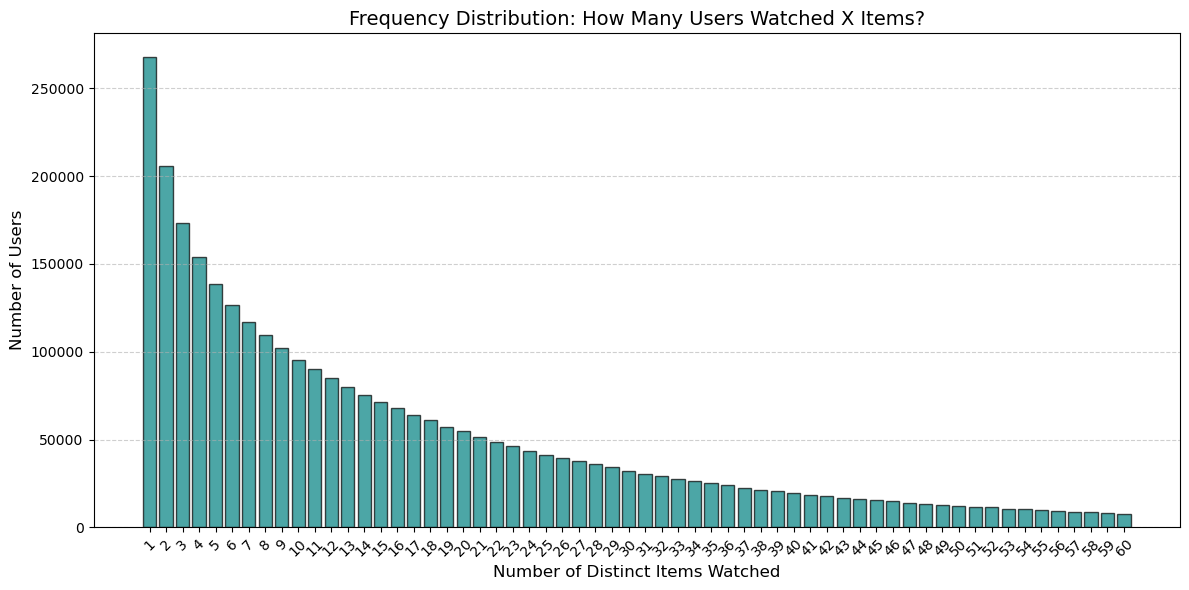

In [17]:
plot_frequency_distribution(train_combined_stats)

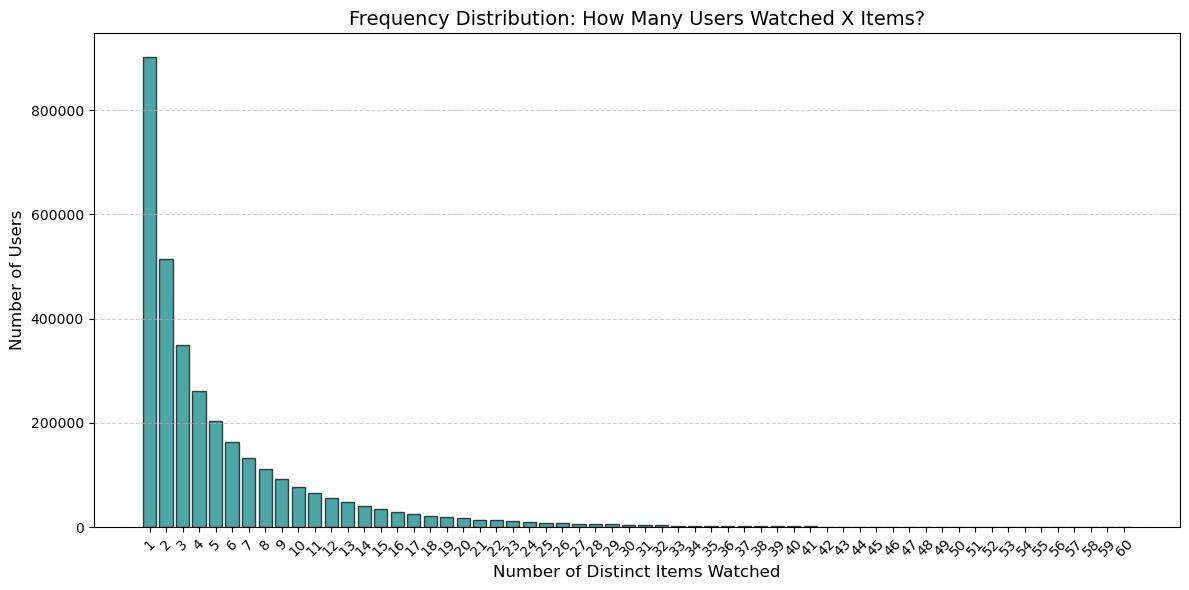

In [18]:
plot_frequency_distribution(test_combined_stats)

In [20]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# --- PART 1: Threshold Counts (Users watching >= X) ---
# We can calculate these using your logic
def compute_threshold_percentile(combined_stats):
    watch_dist = (
    combined_stats
    .groupBy("userid")
    .agg(F.count("item_id").alias("distinct_content_count")) # This gives us the number of distinct items watched per user
    )
    freq_dist_spark = (
    watch_dist
    .groupBy("distinct_content_count")
    .agg(F.count("userid").alias("user_count"))
    .orderBy("distinct_content_count")
    )
    freq_dist_spark.cache()
    thresholds = [1, 2, 3, 5, 10, 20, 50, 100]
    print("--- User Threshold Counts ---")
    for t in thresholds:
        count = freq_dist_spark.filter(f"distinct_content_count >= {t}").agg(F.sum("user_count")).collect()[0][0]  # Sum the user_count for all rows where distinct_content_count >= t
        print(f"Users watching >= {t} content:\t {count}")

    # --- PART 2: Percentiles (Quantiles) ---
    percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    quantile_values = watch_dist.stat.approxQuantile(
        "distinct_content_count", 
        percentiles, 
        0.001  # 0.1% error margin for better accuracy
    )

    print("\n--- User Content Consumption Percentiles ---")
    for p, v in zip(percentiles, quantile_values):
        print(f"{int(p*100)}th Percentile: {int(v)} contents")

compute_threshold_percentile(train_combined_stats)
compute_threshold_percentile(test_combined_stats)

--- User Threshold Counts ---


Exception in thread "serve-DataFrame" java.net.SocketTimeoutException: Accept timed out]
	at java.base/java.net.PlainSocketImpl.socketAccept(Native Method)
	at java.base/java.net.AbstractPlainSocketImpl.accept(AbstractPlainSocketImpl.java:474)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:565)
	at java.base/java.net.ServerSocket.accept(ServerSocket.java:533)
	at org.apache.spark.security.SocketAuthServer$$anon$1.run(SocketAuthServer.scala:65)


Users watching >= 1 content:	 3301707
Users watching >= 2 content:	 3033708
Users watching >= 3 content:	 2827971
Users watching >= 5 content:	 2500754
Users watching >= 10 content:	 1906572
Users watching >= 20 content:	 1159461
Users watching >= 50 content:	 305976
Users watching >= 100 content:	 50275



--- User Content Consumption Percentiles ---
25th Percentile: 5 contents
50th Percentile: 12 contents
75th Percentile: 27 contents
90th Percentile: 47 contents
95th Percentile: 65 contents
99th Percentile: 110 contents
--- User Threshold Counts ---


Users watching >= 1 content:	 3301507
Users watching >= 2 content:	 2399549
Users watching >= 3 content:	 1885728
Users watching >= 5 content:	 1273852
Users watching >= 10 content:	 569644
Users watching >= 20 content:	 150583
Users watching >= 50 content:	 9599
Users watching >= 100 content:	 844



--- User Content Consumption Percentiles ---
25th Percentile: 1 contents
50th Percentile: 3 contents
75th Percentile: 7 contents
90th Percentile: 13 contents
95th Percentile: 19 contents
99th Percentile: 33 contents


26/03/27 10:27:06 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 16 for reason Executor for container container_1764236692086_5823_01_000025 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 10:27:06 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 14 for reason Executor for container container_1764236692086_5823_01_000023 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 10:27:06 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 24 for reason Executor for container container_1764236692086_5823_01_000043 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 10:27:06 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 12 for reason Executor for container container_1764236692086_5

In [ ]:
train_combined_stats.show(5, truncate=False)

+------------------+-----------------------------------------------------+-----------------------+----------------------+
|userId            |item_id                                              |total_playtime_combined|distinct_content_count|
+------------------+-----------------------------------------------------+-----------------------+----------------------+
|-07LdbjtwoQx3h0vK0|CHAUPAL_MOVIE_en_72678f6e-e2c9-4a80-8b3a-e82efa0481d3|7817.0                 |12                    |
|-07LdbjtwoQx3h0vK0|CHAUPAL_MOVIE_en_1b7cda78-4933-442c-be59-6b5aa10ac573|6.0                    |12                    |
|-07LdbjtwoQx3h0vK0|CHAUPAL_MOVIE_en_e4a96136-5a86-44b2-8847-f15510743aaf|7871.0                 |12                    |
|-07LdbjtwoQx3h0vK0|CHAUPAL_MOVIE_en_e5ffc10b-2fe0-4083-8af6-c793df9cef88|7564.0                 |12                    |
|-07LdbjtwoQx3h0vK0|LIONSGATEPLAY_MOVIE_JOHNRAMBOY2008M                  |48.0                   |12                    |
+------------------+----

26/03/27 06:53:53 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 24 for reason Executor for container container_1764236692086_5800_01_000027 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 06:53:53 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 22 for reason Executor for container container_1764236692086_5800_01_000025 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 06:53:53 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 6 for reason Executor for container container_1764236692086_5800_01_000007 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/27 06:53:53 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 7 for reason Executor for container container_1764236692086_580

## Graph testing 1

In [ ]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprint
streamable_df = (
    train_df.select(
        "userId",
        "content_id", 
        "total_play_time_sec",
        "content_content_type"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

In [30]:
combined_playtime = (
    streamable_df.select("userid", "content_id", "total_play_time_sec", "content_content_type")  # Repartition for better parallelization
    .groupBy("userid", "content_id", "content_content_type")
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined"),
        F.count("*").alias("num_sessions")
    )
)

### testing dists

In [ ]:
from pyspark.sql import functions as F

watch_dist = (
    combined_playtime.groupBy("content_content_type")
      .agg(F.sum("total_playtime_combined").alias("total_watch_time"))
)

watch_dist.show()

+--------------------+--------------------+
|content_content_type|    total_watch_time|
+--------------------+--------------------+
|               MOVIE| 6.841097019119993E8|
|             EPISODE|1.0156314415769988E9|
|              SEASON|             22123.0|
|               VIDEO|5.0585796662999995E7|
|              TVSHOW|          141001.034|
+--------------------+--------------------+



26/03/06 10:33:28 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 4 for reason Executor for container container_1764236692086_4612_01_000007 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


In [ ]:
user_pref = (
    combined_playtime.groupBy("userid", "content_content_type")
      .agg(F.sum("total_playtime_combined").alias("watch_time"))
).orderBy("userid").show()

26/03/06 10:36:03 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 1 for reason Executor for container container_1764236692086_4612_01_000003 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


+------------------+--------------------+------------------+
|            userid|content_content_type|        watch_time|
+------------------+--------------------+------------------+
|                  |               MOVIE|           30682.0|
|                  |             EPISODE|            3547.0|
|--03-VasNdpfk0Fa20|               MOVIE|3494.3810000000003|
|--17p0Yk5D3V9JME40|               MOVIE|            3999.0|
|--1o8po0M4ISH2BO50|             EPISODE|          1324.704|
|--1x4ql9mzvdg-3Ir0|             EPISODE|          5227.995|
|--1x4ql9mzvdg-3Ir0|               MOVIE|          3110.589|
|--2FN_l_OOXV9M1hg0|             EPISODE|          1214.318|
|--2rOSAcWozwI0Qer0|               MOVIE|          1645.955|
|--3NKB8gzI3SlEDyn0|               MOVIE|          2778.552|
|--3hWdDYnhvQQWQON0|               MOVIE|            5572.0|
|--41ldMrROFBLl64r0|               MOVIE|           210.964|
|--41ldMrROFBLl64r0|             EPISODE|           262.547|
|--4Rlo_Vwz0YMy2Yw0|    

26/03/06 10:37:12 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 6 for reason Executor for container container_1764236692086_4612_01_000009 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


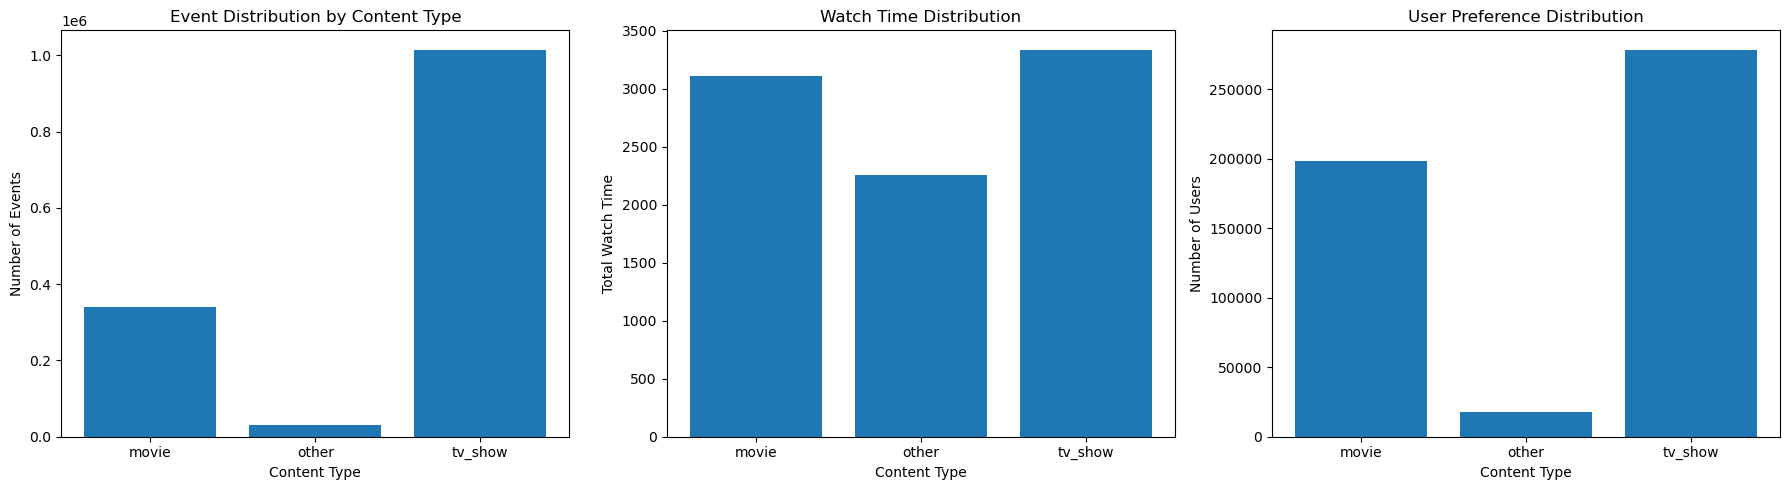

In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Normalize content types
# -----------------------------

df_clean = combined_playtime.withColumn(
    "content_type_grouped",
    F.when(F.lower(F.col("content_content_type")).isin("episode", "tvshow", "tv show", "tv_shows"), "tv_show")
     .when(F.lower(F.col("content_content_type")).isin("movie", "film"), "movie")
     .otherwise("other")
)

# -----------------------------
# 2. EVENT DISTRIBUTION
# -----------------------------

event_dist = (
    df_clean
    .groupBy("content_type_grouped")
    .count()
)

event_pd = event_dist.toPandas()

# -----------------------------
# 3. WATCH TIME DISTRIBUTION
# -----------------------------

watch_dist = (
    df_clean
    .groupBy("content_type_grouped", "userid")
    .agg(F.sum("total_playtime_combined").alias("user_watch_time"))
    .groupBy("content_type_grouped")
    .agg(F.avg("user_watch_time").alias("avg_watch_time"))
)

watch_pd = watch_dist.toPandas()

# -----------------------------
# 4. USER PREFERENCE DISTRIBUTION
# -----------------------------

user_watch = (
    df_clean
    .groupBy("userid", "content_type_grouped")
    .agg(F.sum("total_playtime_combined").alias("watch_time"))
)

from pyspark.sql.window import Window

window = Window.partitionBy("userid").orderBy(F.col("watch_time").desc())

user_pref = (
    user_watch
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") == 1)
    .groupBy("content_type_grouped")
    .count()
)

user_pref_pd = user_pref.toPandas()

# -----------------------------
# 5. VISUALIZATIONS
# -----------------------------

fig, axes = plt.subplots(1,3, figsize=(18,5))

# Event distribution
axes[0].bar(event_pd["content_type_grouped"], event_pd["count"])
axes[0].set_title("Event Distribution by Content Type")
axes[0].set_xlabel("Content Type")
axes[0].set_ylabel("Number of Events")

# Watch time distribution
axes[1].bar(watch_pd["content_type_grouped"], watch_pd["avg_watch_time"])
axes[1].set_title("Watch Time Distribution")
axes[1].set_xlabel("Content Type")
axes[1].set_ylabel("Total Watch Time")

# User preference distribution
axes[2].bar(user_pref_pd["content_type_grouped"], user_pref_pd["count"])
axes[2].set_title("User Preference Distribution")
axes[2].set_xlabel("Content Type")
axes[2].set_ylabel("Number of Users")

plt.tight_layout()
plt.show()

## count of content watched per user

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Recommendation_Engine_tinker") \
    .getOrCreate()

In [ ]:
from datetime import datetime, timedelta

date = "2026-03-05"
base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"
date_format = "%Y-%m-%d"

base_date = datetime.strptime(date, date_format)

paths = [
    f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(30)
]

df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if df is None:
            df = temp_df
        else:
            df = df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")

1. Select importatnt columns
2. count the number of instances
3. group by count of instances
4. get count and distribution of this group

In [9]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprint
streamable_df = (
    df.select(
        "userId",
        "content_id", 
        "total_play_time_sec",
        "content_content_type"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

combined_playtime = (
    streamable_df.select("userid", "content_id", "total_play_time_sec", "content_content_type")  # Repartition for better parallelization
    .groupBy("userid", "content_id", "content_content_type")
    .agg(
        F.sum("total_play_time_sec").alias("playtime_sec"),
        F.count("*").alias("num_sessions")
    )
)


In [ ]:
user_distinct_content_count_df.show(10, truncate=False)

+------------------+----------------------+
|userid            |distinct_content_count|
+------------------+----------------------+
|Vu8tZ0dpHxYpQVUHm0|122                   |
|QgCU_vKdz81wagBLt0|52                    |
|_-pZkThbdN4k3738l0|17                    |
|O-xRAhKf21bGYSpta0|2                     |
|Hud8e_LaCWchNEBLS0|2                     |
|bCLzRJ8579MfsgdLj0|15                    |
|Z--qkq4v8NvLBKwJA0|17                    |
|262r-3LS0I_i8YWg-0|7                     |
|pktZjfUgHDAGA-wAp0|9                     |
|WSnug4TOCZ8fHC8GZ0|30                    |
+------------------+----------------------+
only showing top 10 rows



26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 15 for reason Executor for container container_1764236692086_4733_01_000015 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 4 for reason Executor for container container_1764236692086_4733_01_000004 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 13 for reason Executor for container container_1764236692086_4733_01_000013 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


In [13]:
from pyspark.sql import functions as F

user_distinct_content_count_df = (
    combined_playtime
    .filter(F.col("playtime_sec") > 300)
    .groupBy("userid")
    .agg(F.count_distinct("content_id").alias("distinct_content_count"))
).cache()

/tmp/ipykernel_3520773/3931902583.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


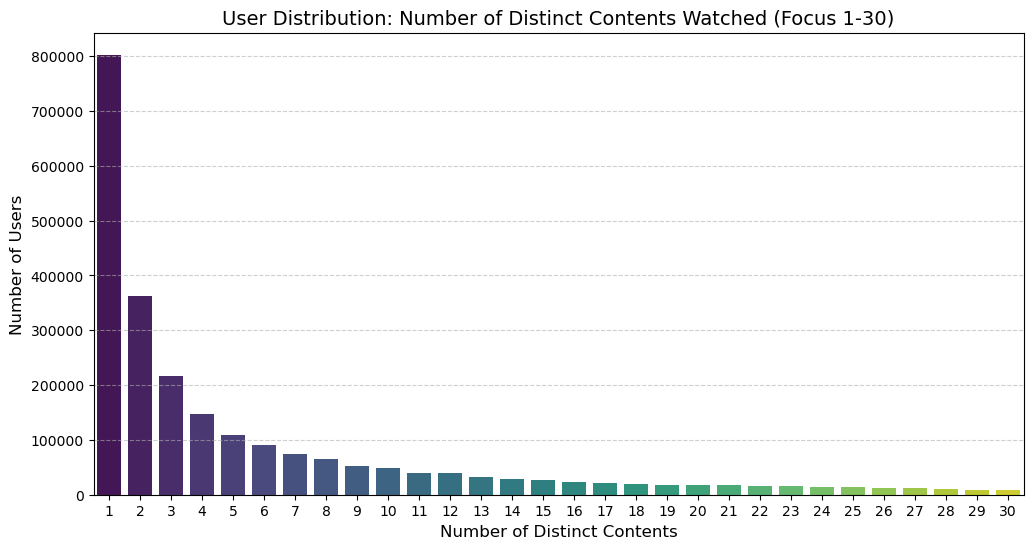

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate: Count how many users fall into each "content count" bucket
# We sort by the count of contents to make the X-axis linear (1, 2, 3...)
dist_data = (
    user_distinct_content_count_df
    .groupBy("distinct_content_count")
    .count()
    .orderBy("distinct_content_count")
)

# 2. Focus on "Lower Numbers": Filter for users with 1 to 30 contents 
# This prevents high-count outliers from squishing the graph
plot_df = dist_data.filter("distinct_content_count <= 30").toPandas()
# plot_df = dist_data.toPandas()

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x="distinct_content_count", 
    y="count", 
    data=plot_df, 
    palette="viridis"
)

# Adding labels and styling
plt.title("User Distribution: Number of Distinct Contents Watched (Focus 1-30)", fontsize=14)
plt.xlabel("Number of Distinct Contents", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [20]:
print("Users watching >= 1 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 1").count())
print("Users watching >= 2 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 2").count())
print("Users watching >= 3 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 3").count())
print("Users watching >= 5 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 5").count())
print("Users watching >= 10 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 10").count())
print("Users watching >= 20 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 20").count())
print("Users watching >= 50 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 50").count())
print("Users watching >= 100 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 100").count())

Users watching >= 1 content:	 2520461
Users watching >= 2 content:	 1717764
Users watching >= 3 content:	 1355891
Users watching >= 5 content:	 992378
Users watching >= 10 content:	 599529
Users watching >= 20 content:	 299764
Users watching >= 50 content:	 62172
Users watching >= 100 content:	 16649


In [23]:
# Define the percentiles you want (expressed as decimals 0.0 to 1.0)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Calculate the values
# 0.01 is the relative error: lower is more accurate but slower
quantile_values = user_distinct_content_count_df.stat.approxQuantile(
    "distinct_content_count", 
    percentiles, 
    0.01
)

# Pair them up and print the results
print("--- User Content Consumption Percentiles ---")
for p, v in zip(percentiles, quantile_values):
    print(f"{int(p*100)}th Percentile: {int(v)} contents")

--- User Content Consumption Percentiles ---
25th Percentile: 1 contents
50th Percentile: 3 contents
75th Percentile: 9 contents
90th Percentile: 21 contents
95th Percentile: 31 contents
99th Percentile: 3048 contents
